
# Lab1_3: PDE

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

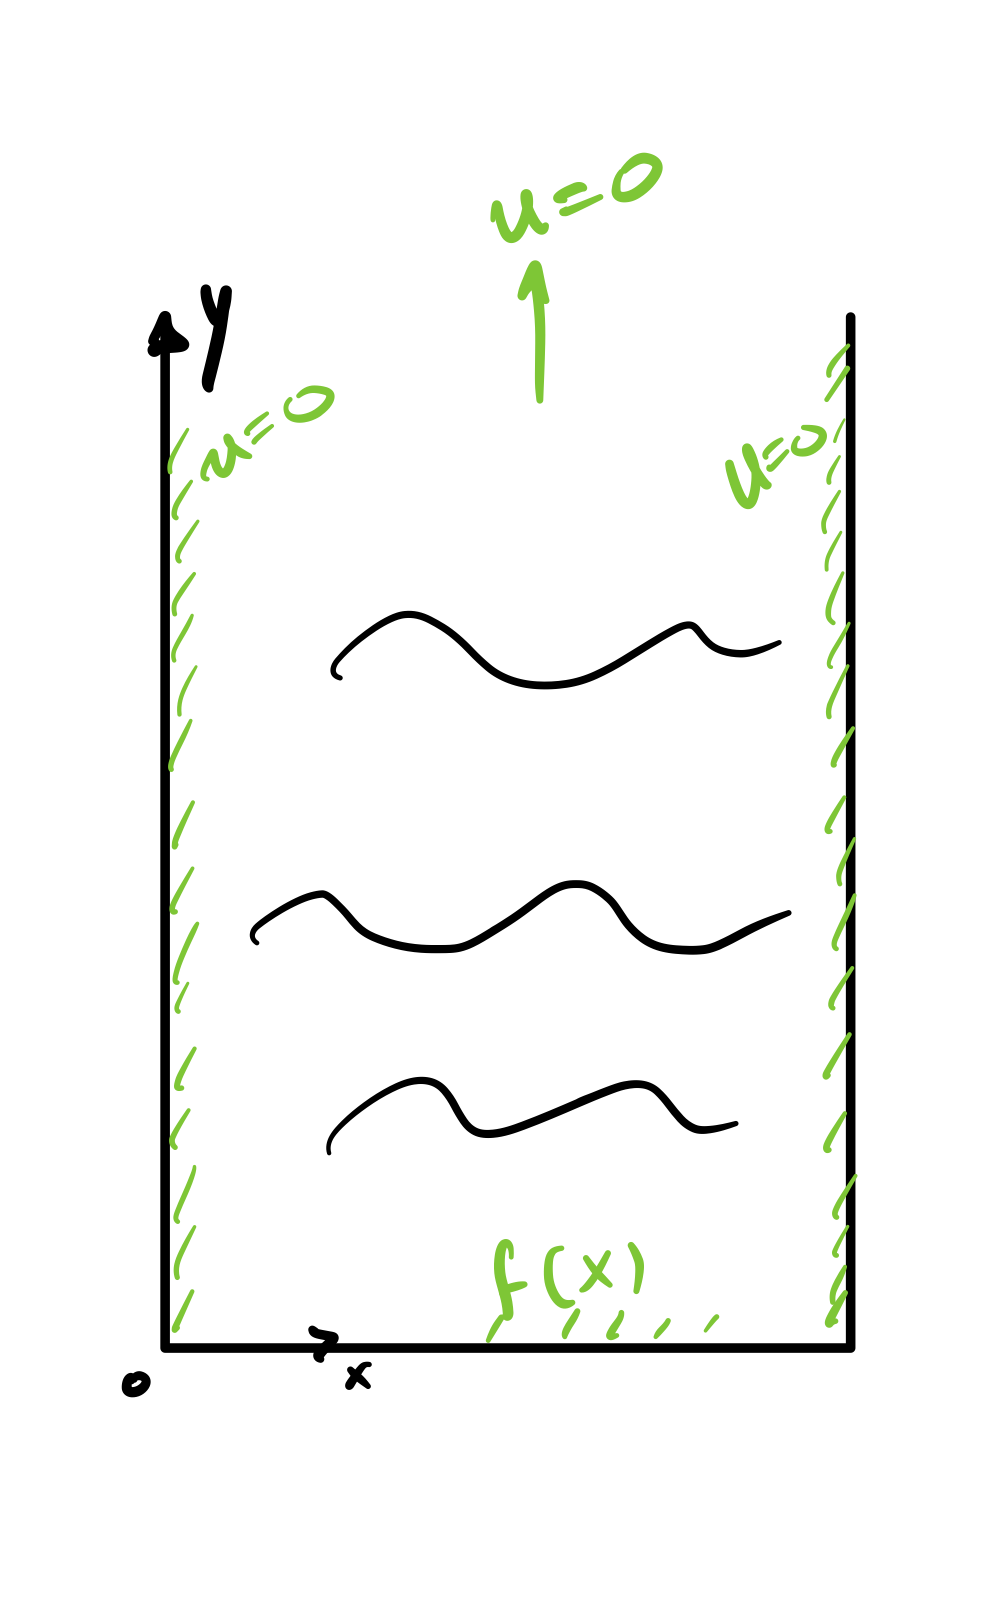

In [6]:
from IPython.display import Image
Image(filename=path+filename4, width=300)

# Exercise 1

## Part 1
We use tolerance $err = 10^{-2}$

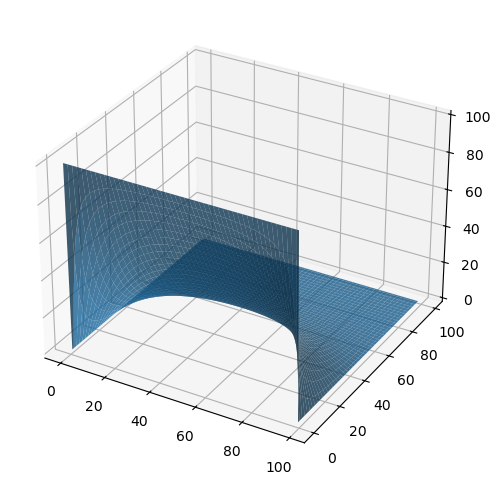

In [29]:
import numpy as np
import matplotlib.pyplot as plt
Nx,Ny = 100, 100

niter = 50
err = 1e-2

U = np.zeros((Nx, Ny))
Uaux = np.zeros((Nx,Ny))

U[:, 0] = 100

for x in range(1, Nx-1):
    for y in range(1, Ny-1):
        U[x,y] = 0.25*(Uaux[x-1, y] + Uaux[x+1, y] + Uaux[x, y-1] + Uaux[x, y+1])

while np.max(np.abs(U-Uaux)) > err:
    Uaux = U.copy()
    U[1:-1,1:-1] = 0.25*(
        Uaux[0:-2,1:-1]+Uaux[2:,1:-1]+
        Uaux[1:-1,0:-2]+Uaux[1:-1,2:]
    )


X, Y = np.meshgrid(
    np.arange(Nx),
    np.arange(Ny)
)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, U[X,Y], alpha=0.8)

## Part 2

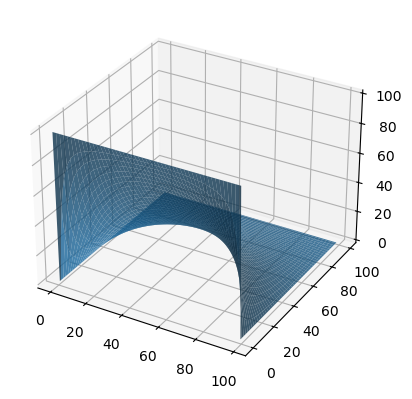

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
Nx,Ny = 100, 100

niter = 50
err = 1e-3

U = np.zeros((Nx, Ny))
Uaux = np.zeros((Nx,Ny))

U[:, 0] = 100

for x in range(1, Nx-1):
    for y in range(1, Ny-1):
        U[x,y] = 0.25*(Uaux[x-1, y] + Uaux[x+1, y] + Uaux[x, y-1] + Uaux[x, y+1])

while np.max(np.abs(U-Uaux)) > err:
    Uaux = U.copy()
    U[1:-1, 1:-1] = 0.25 * (
        Uaux[0:-2, 1:-1] + Uaux[2:, 1:-1] +
        Uaux[1:-1, 0:-2] + Uaux[1:-1, 2:]
    )

X, Y = np.meshgrid(
    np.arange(Nx),
    np.arange(Ny)
)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, U[X,Y], alpha=0.8)

## Part 3
The fourier series that solves this laplace PDE is
$$
U(x,y) = \sum_{n = 1,3,5,...}^\infty \frac{400}{n\pi\sinh(n\pi)} \sin\left(\frac{n\pi x}L\right)\sinh\left(\frac{n\pi(L-y)}L\right)
$$

In [66]:
def fourier_series(x, y, L = Nx, N = 5):
    return np.sum(
    [400/(n*np.pi*np.sinh(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L) for n in range(1,2*N,2)],
    axis = 0
    )

n_fourier = 1
while np.max(abs(fourier_series(X,Y, N = n_fourier-1) - fourier_series(X,Y, N = n_fourier))) > 1e-3:
    n_fourier += 1

n_differences = 1

U = np.zeros((Nx, Ny))
Uaux = np.zeros((Nx,Ny))

U[:, 0] = 100

for x in range(1, Nx-1):
    for y in range(1, Ny-1):
        U[x,y] = 0.25*(Uaux[x-1, y] + Uaux[x+1, y] + Uaux[x, y-1] + Uaux[x, y+1])

while np.max(np.abs(U-Uaux)) > 1e-3:
    Uaux = U.copy()
    U[1:-1, 1:-1] = 0.25 * (
        Uaux[0:-2, 1:-1] + Uaux[2:, 1:-1] +
        Uaux[1:-1, 0:-2] + Uaux[1:-1, 2:]
    )
    n_differences += 1

print(f"Iteraciones fourier: {n_fourier}\nIteraciones diferencias finitas: {n_differences}")

/tmp/ipykernel_662669/717921470.py:3: RuntimeWarning: overflow encountered in scalar multiply
  [400/(n*np.pi*np.sinh(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L) for n in range(1,2*N,2)],


Iteraciones fourier: 113
Iteraciones diferencias finitas: 5992


# Exercise 2
The analytical solution is
$$
U(x,y) = u_0\sin\left(2\pi x/L\right) e^{-2\pi y/L}
$$

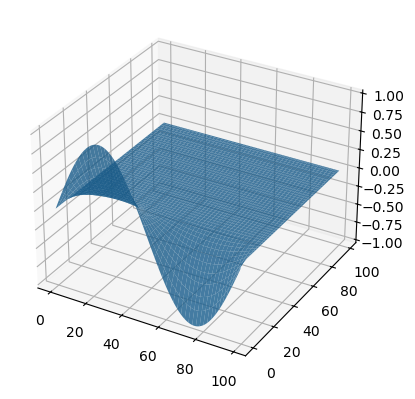

In [69]:
Nx,Ny = 100, 100

niter = 50
err = 1e-3

U = np.zeros((Nx, Ny))
Uaux = np.zeros((Nx,Ny))

U[:, 0] = np.sin(2*np.pi*np.arange(Nx)/Nx)

for x in range(1, Nx-1):
    for y in range(1, Ny-1):
        U[x,y] = 0.25*(Uaux[x-1, y] + Uaux[x+1, y] + Uaux[x, y-1] + Uaux[x, y+1])

while np.max(np.abs(U-Uaux)) > err:
    Uaux = U.copy()
    U[1:-1, 1:-1] = 0.25 * (
        Uaux[0:-2, 1:-1] + Uaux[2:, 1:-1] +
        Uaux[1:-1, 0:-2] + Uaux[1:-1, 2:]
    )

X, Y = np.meshgrid(
    np.arange(Nx),
    np.arange(Ny)
)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, U[X,Y], alpha=0.8)